# Explorative Analysis

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

In [78]:
# Read data
events = pd.read_csv("Data/V2/mouse_events_1601_norm.csv")
hovers = pd.read_csv("Data/V2/mouse_hovers_1601.csv")
velocity = pd.read_csv("Data/V2/velocity_metrics_1601_norm.csv")
df = pd.read_csv("Data/V2/df.csv")


In [79]:
# Merge Condition to Events and Hovers
events = events.merge(df[["participant_id","interest"]], on="participant_id", how="inner")
hovers = hovers.merge(df[["participant_id","interest"]], on="participant_id", how="inner")


# (optional) verify
print("Remaining participants in events:", events["participant_id"].nunique())
print("Remaining participants in hovers:", hovers["participant_id"].nunique())

Remaining participants in events: 96
Remaining participants in hovers: 96


## Mouse Visualizations by Interest

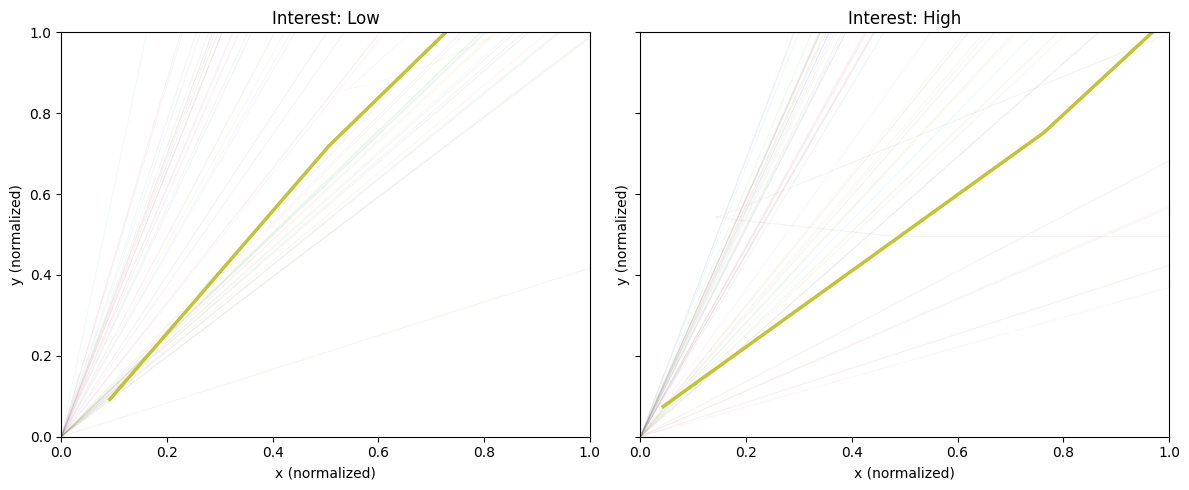

In [80]:
# Basic cleaning
events = events.dropna(subset=["participant_id", "t_ms", "x_norm", "y_norm", "interest"])

# Sort for proper lines
events = events.sort_values(["interest", "participant_id", "t_ms"])

# Helper: resample each trajectory onto a common time grid (0..1) so we can compute mean path
def resample_path(g, n=100):
    g = g.sort_values("t_ms")
    t = g["t_ms"].to_numpy()
    x = g["x_norm"].to_numpy()
    y = g["y_norm"].to_numpy()
    if len(t) < 2:
        return None
    tn = (t - t[0]) / (t[-1] - t[0]) if t[-1] > t[0] else np.linspace(0, 1, len(t))
    grid = np.linspace(0, 1, n)
    xg = np.interp(grid, tn, x)
    yg = np.interp(grid, tn, y)
    return pd.DataFrame({"grid": grid, "x": xg, "y": yg})

# Compute mean path per interest
mean_paths = {}
for interest_level, sub in events.groupby("interest"):
    resampled = []
    for (_, _task, _pid), g in sub.groupby(["participant_id", "task", "participant_id"]):
        out = resample_path(g, n=120)
        if out is not None:
            resampled.append(out)
    if resampled:
        R = pd.concat(resampled, ignore_index=True)
        mean_path = R.groupby("grid", as_index=False)[["x","y"]].mean()
        mean_paths[interest_level] = mean_path

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, interest_level in zip(axes, ["Low", "High"]):
    sub = events[events["interest"] == interest_level]
    ax.set_title(f"Interest: {interest_level}")
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")

    # Spaghetti lines (sample participants if too many)
    groups = list(sub.groupby(["participant_id","task"]))
    # sample up to 50 trajectories for readability
    if len(groups) > 50:
        np.random.seed(1)
        groups = list(np.random.choice(groups, size=50, replace=False))

    for (_, _), g in groups:
        g = g.sort_values("t_ms")
        ax.plot(g["x_norm"], g["y_norm"], linewidth=0.7, alpha=0.08)

    # Mean path overlay
    if interest_level in mean_paths:
        mp = mean_paths[interest_level]
        ax.plot(mp["x"], mp["y"], linewidth=2.5, alpha=0.9)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


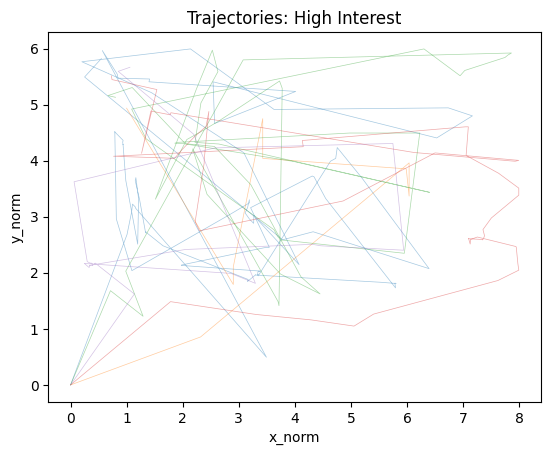

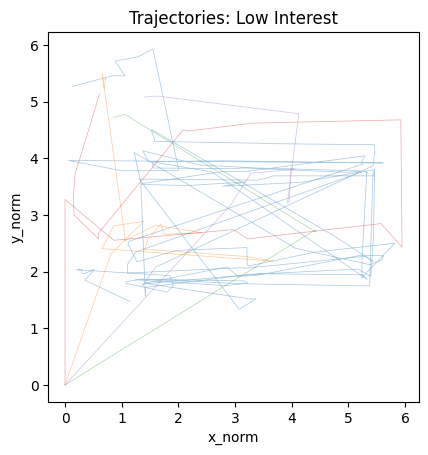

In [83]:
# Merge Condition to Events and Hovers
events = events.merge(df[["participant_id","interest"]], on="participant_id", how="inner")

# Sort values in events and calculate velocity per event
events = events.sort_values(["participant_id","t_ms"])
events["dt_s"] = events.groupby("participant_id")["t_ms"].diff() / 1000.0
events["dx"]   = events.groupby("participant_id")["x_norm"].diff()
events["dy"]   = events.groupby("participant_id")["y_norm"].diff()
events["velocity"]= np.sqrt(events["dx"]**2 + events["dy"]**2) / np.clip(events["dt_s"], 1e-6, None)

# Merge events with velocity and 
df2 = events.merge(df, on="participant_id", how="inner") \
           .merge(velocity[["participant_id","mean_velocity_norm_s"]], on="participant_id", how="inner")
df2 = df2.dropna(subset=["interest"])

# downsample
df2 = df2.groupby("participant_id").nth(list(range(0, 10_000_000, 10))).reset_index()

# sample participants per interest
keep = (df2[["participant_id","interest"]].drop_duplicates()
          .groupby("interest").sample(n=5, random_state=2)["participant_id"])
df2 = df2[df2["participant_id"].isin(keep)]

for interest, g in df2.groupby("interest"):
    plt.figure()
    for pid, p in g.groupby("participant_id"):
        plt.plot(p["x_norm"], p["y_norm"], alpha=0.4, linewidth=0.5)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Trajectories: {interest} Interest")
    plt.xlabel("x_norm"); plt.ylabel("y_norm")
    plt.show()


Website dahnter legen -> Später nochmal testen

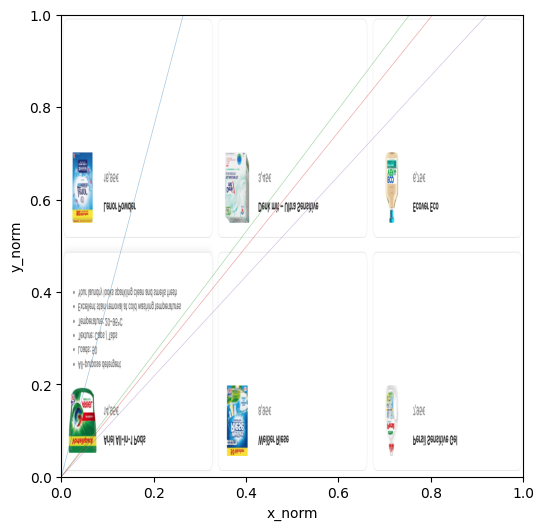

In [ ]:
# Hintergrundbild laden (Pfad anpassen)
bg = mpimg.imread("Data/High Load.png")  # z.B. screenshot der Seite

fig, ax = plt.subplots(figsize=(6, 6))

# Hintergrund zeichnen:
# extent=[xmin, xmax, ymin, ymax] muss zu deinen Koordinaten passen (hier 0..1)
ax.imshow(bg, extent=[0, 1, 0, 1], origin="lower")

# Trajektorien drüber plotten (Beispiel: eine Gruppe g mit x_norm/y_norm)
for pid, p in g.groupby("participant_id"):
    ax.plot(p["x_norm"], p["y_norm"], alpha=0.4, linewidth=0.5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x_norm")
ax.set_ylabel("y_norm")

plt.show()


## Trajectories with Color Coding

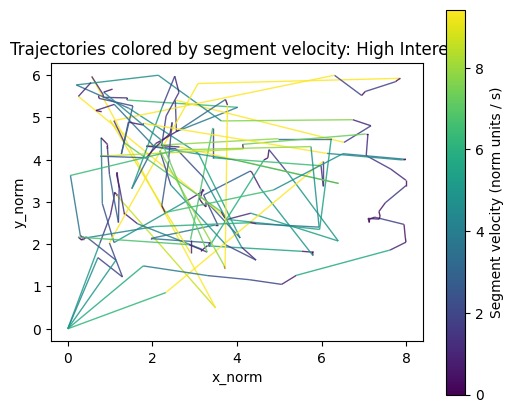

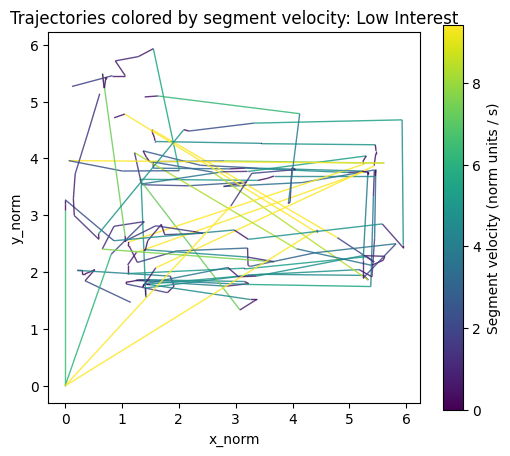

In [84]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ---- helper: compute segment velocities from consecutive points ----
def segment_velocity(x, y, t_ms, eps=1e-6):
    dt = np.diff(t_ms) / 1000.0
    dx = np.diff(x)
    dy = np.diff(y)
    v = np.sqrt(dx*dx + dy*dy) / np.clip(dt, eps, None)  # velocity per segment
    return v

# optional: global color normalization across all segments shown (recommended)
# compute vmin/vmax from the ACTUAL segment velocities (not participant aggregates)
all_v = []
for _, p in df2.sort_values(["participant_id", "t_ms"]).groupby("participant_id"):
    p = p.dropna(subset=["x_norm", "y_norm", "t_ms"])
    if len(p) < 2:
        continue
    v_seg = segment_velocity(p["x_norm"].to_numpy(), p["y_norm"].to_numpy(), p["t_ms"].to_numpy())
    all_v.append(v_seg)

if all_v:
    all_v = np.concatenate(all_v)
    vmin, vmax = np.quantile(all_v, [0.01, 0.99])  # robust scaling
else:
    vmin, vmax = 0.0, 1.0

norm = Normalize(vmin=vmin, vmax=vmax)

# ---- plot trajectories colored by segment velocity ----
for interest, g in df2.sort_values(["participant_id", "t_ms"]).groupby("interest"):
    fig, ax = plt.subplots(figsize=(6, 5))

    for pid, p in g.groupby("participant_id"):
        p = p.dropna(subset=["x_norm", "y_norm", "t_ms"])
        if len(p) < 2:
            continue

        x = p["x_norm"].to_numpy()
        y = p["y_norm"].to_numpy()
        t = p["t_ms"].to_numpy()

        # segments: (n-1) line pieces
        pts = np.column_stack([x, y]).reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

        # velocity per segment computed from consecutive points
        v_seg = segment_velocity(x, y, t)

        lc = LineCollection(segs, cmap="viridis", norm=norm)
        lc.set_array(v_seg)
        lc.set_linewidth(1.0)
        lc.set_alpha(0.85)
        ax.add_collection(lc)

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()
    ax.set_title(f"Trajectories colored by segment velocity: {interest} Interest")
    ax.set_xlabel("x_norm")
    ax.set_ylabel("y_norm")

    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax)
    cbar.set_label("Segment velocity (norm units / s)")

    plt.show()


## Different Phases

In [ ]:
# -----------------------------
# 2) Helper: early/late phase per participant × task
# -----------------------------
keys = ["participant_id", "task"]  # adjust if your file uses different columns

time_window = (
    events.groupby(keys, as_index=False)["t_ms"]
    .agg(t_start="min", t_end="max")
)
time_window["t_span"] = time_window["t_end"] - time_window["t_start"]

# -----------------------------
# 3) Event-level velocity + phase
# -----------------------------
events_dyn = events.merge(time_window, on=keys, how="inner").copy()

# Avoid division by zero if someone has only one timestamp or zero span
events_dyn = events_dyn[events_dyn["t_span"] > 0].copy()

events_dyn["rel_time"] = (events_dyn["t_ms"] - events_dyn["t_start"]) / events_dyn["t_span"]
events_dyn["phase"] = np.select(
    [events_dyn["rel_time"] <= 0.30, events_dyn["rel_time"] >= 0.70],
    ["early", "late"],
    default="mid"
)

events_dyn = events_dyn.sort_values(keys + ["t_ms"])

# Compute step-to-step differences within participant × task
for col in ["t_ms", "x_norm", "y_norm"]:
    if col not in events_dyn.columns:
        raise ValueError(f"Expected column '{col}' in events data but did not find it.")

events_dyn["dt_s"] = events_dyn.groupby(keys)["t_ms"].diff() / 1000.0  # ms -> seconds
events_dyn["dx"] = events_dyn.groupby(keys)["x_norm"].diff()
events_dyn["dy"] = events_dyn.groupby(keys)["y_norm"].diff()

events_dyn["step_dist"] = np.sqrt(events_dyn["dx"]**2 + events_dyn["dy"]**2)

# Velocity (handle dt<=0)
events_dyn["velocity"] = np.where(events_dyn["dt_s"] > 0, events_dyn["step_dist"] / events_dyn["dt_s"], np.nan)

# Pause threshold (tune!)
pause_thresh = 0.001  # norm-units per second
events_dyn["is_pause"] = events_dyn["velocity"] < pause_thresh

# -----------------------------
# 4) Summarise event features: early vs late
# -----------------------------
event_phase_summary = (
    events_dyn.loc[events_dyn["phase"].isin(["early", "late"])]
    .groupby(keys + ["phase"], as_index=False)
    .agg(
        mean_v=("velocity", "mean"),
        med_v=("velocity", "median"),
        p90_v=("velocity", lambda x: np.nanquantile(x, 0.90)),
        pause_rate=("is_pause", "mean"),
        total_dist=("step_dist", "sum"),
    )
)

# -----------------------------
# 5) Hover features: early vs late
#    Assign each hover to a phase by hover midpoint time
# -----------------------------
req_hover_cols = ["t_enter_ms", "t_leave_ms"]
for col in req_hover_cols:
    if col not in hovers.columns:
        raise ValueError(f"Expected column '{col}' in hovers data but did not find it.")

hovers_dyn = hovers.merge(time_window, on=keys, how="inner").copy()
hovers_dyn = hovers_dyn[hovers_dyn["t_span"] > 0].copy()

# Use duration_ms if present; else compute from enter/leave
if "duration_ms" not in hovers_dyn.columns:
    hovers_dyn["duration_ms"] = hovers_dyn["t_leave_ms"] - hovers_dyn["t_enter_ms"]

hovers_dyn["t_mid"] = (hovers_dyn["t_enter_ms"] + hovers_dyn["t_leave_ms"]) / 2.0
hovers_dyn["rel_time"] = (hovers_dyn["t_mid"] - hovers_dyn["t_start"]) / hovers_dyn["t_span"]
hovers_dyn["phase"] = np.select(
    [hovers_dyn["rel_time"] <= 0.30, hovers_dyn["rel_time"] >= 0.70],
    ["early", "late"],
    default="mid"
)

hover_phase_summary = (
    hovers_dyn.loc[hovers_dyn["phase"].isin(["early", "late"])]
    .groupby(keys + ["phase"], as_index=False)
    .agg(
        hover_ms=("duration_ms", "sum"),
        n_hovers=("duration_ms", "size"),
    )
)

# -----------------------------
# 6) Combine + compute change scores (late - early)
# -----------------------------
dyn = event_phase_summary.merge(hover_phase_summary, on=keys + ["phase"], how="left")
dyn[["hover_ms", "n_hovers"]] = dyn[["hover_ms", "n_hovers"]].fillna(0)

dyn_wide = dyn.pivot_table(
    index=keys,
    columns="phase",
    values=["mean_v", "med_v", "p90_v", "pause_rate", "total_dist", "hover_ms", "n_hovers"],
    aggfunc="first"
)

# Flatten multi-index columns: e.g., ("mean_v","early") -> "mean_v_early"
dyn_wide.columns = [f"{a}_{b}" for a, b in dyn_wide.columns]
dyn_wide = dyn_wide.reset_index()

# Change scores: late - early
dyn_wide["d_mean_v"]   = dyn_wide["mean_v_late"]   - dyn_wide["mean_v_early"]
dyn_wide["d_pause"]    = dyn_wide["pause_rate_late"] - dyn_wide["pause_rate_early"]
dyn_wide["d_dist"]     = dyn_wide["total_dist_late"] - dyn_wide["total_dist_early"]
dyn_wide["d_hover_ms"] = dyn_wide["hover_ms_late"] - dyn_wide["hover_ms_early"]
dyn_wide["d_n_hovers"] = dyn_wide["n_hovers_late"] - dyn_wide["n_hovers_early"]

# -----------------------------
# 7) Merge with conditions + run regressions (optional)
# -----------------------------
# Example: if df exists with participant_id, interest, load
# dyn_wide = dyn_wide.merge(df[["participant_id","interest","load"]], on="participant_id", how="left")

# If interest/load are 0/1, you can keep them numeric.
# If they are strings "Low"/"High", statsmodels will handle them as categorical with C() in formula.

# Example regression: does temporal change in velocity depend on Interest × Load?
import statsmodels.formula.api as smf

# Make sure interest/load are in dyn_wide (after merge)
# model = smf.ols("d_mean_v ~ C(interest) * C(load)", data=dyn_wide).fit()
# print(model.summary())

# Another example: hover dynamics
# model_hover = smf.ols("d_hover_ms ~ C(interest) * C(load)", data=dyn_wide).fit()
# print(model_hover.summary())

# -----------------------------
# 8) Quick check outputs
# -----------------------------
print(dyn_wide.head())
